# Week 9 Challenge

# Task 3 - Forecast Future Market Trends

Author: Lalise Fufi

Date: July 2026

Objective:
Use the best-performing model from Task 2 (LSTM) to forecast Tesla's future
closing price 6-12 months beyond the end of the historical dataset
(30 June 2026), visualize the forecast with confidence intervals, and
translate the results into actionable business insights for GMF's
investment committee.

**Recap from Task 2:** Two models were built and compared — ARIMA and LSTM.
The LSTM model produced the lower MAE, RMSE and MAPE on the 2025-2026 test
set, so **LSTM is the model carried forward into Task 3** for generating the
future forecast.

1. Import Libraries

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.plotting.register_matplotlib_converters()

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

plt.style.use("ggplot")


2. Load Tesla Data

In [2]:
# ==========================================================
# Load Tesla Data (same cleaned source used in Task 1 / Task 2)
# ==========================================================

tsla = pd.read_csv(
    "../data/raw/TSLA.csv",
    skiprows=[1],
    index_col=0,
    parse_dates=True
)

tsla.index.name = "Date"

close = tsla["Close"].sort_index()

# Drop the stray non-numeric header row that sometimes survives the
# yfinance multi-index CSV export (same issue handled in Task 2)
close = pd.to_numeric(close, errors="coerce").dropna()

print("Data range:", close.index.min(), "to", close.index.max())
print("Number of trading days:", len(close))
close.tail()


Data range: 2015-01-02 to 2026-06-29
Number of trading days: 2888


Date
2026-06-23    381.609985
2026-06-24    375.529999
2026-06-25    375.119995
2026-06-26    379.709991
2026-06-29    411.839996
Name: Close, dtype: float64

3. Recreate the Chronological Train/Test Split

This mirrors Task 2 exactly (Train: 2015-2024, Test: 2025-2026). We rebuild it here so that the final chart can clearly separate **historical data**, **test-period predictions**, and the **future forecast**.

In [3]:
train = close[:'2024-12-31']
test = close['2025-01-01':]

print("Train shape:", train.shape)
print("Test shape :", test.shape)


Train shape: (2516,)
Test shape : (372,)


4. Scale Data and Build Sequences (Window = 60 Days)

Same preprocessing as Task 2: MinMax scale the closing price and build sliding windows of 60 past days to predict the next day.

In [4]:
WINDOW = 60

scaler = MinMaxScaler()
scaled_full = scaler.fit_transform(close.values.reshape(-1, 1))

def make_sequences(data, window=WINDOW):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(scaled_full)

split = len(train)
X_train, y_train = X_all[:split - WINDOW], y_all[:split - WINDOW]
X_test, y_test = X_all[split - WINDOW:], y_all[split - WINDOW:]

print("X_train:", X_train.shape, "X_test:", X_test.shape)


X_train: (2456, 60, 1) X_test: (372, 60, 1)


5. Build and Train the LSTM on the Training Set

Identical architecture to Task 2, trained only on the training portion. This model is used purely to reproduce the test-period predictions for the comparison chart below.

In [5]:
def build_lstm(window=WINDOW):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(window, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model

test_model = build_lstm()

test_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - loss: 0.0104 - val_loss: 0.0028
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0015 - val_loss: 0.0028
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0011 - val_loss: 0.0073
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0010 - val_loss: 0.0027
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 9.

6. Generate Test-Period Predictions (for the comparison chart)

In [6]:
test_pred_scaled = test_model.predict(X_test)

test_pred = scaler.inverse_transform(test_pred_scaled).flatten()
test_actual = scaler.inverse_transform(y_test).flatten()

# align index: predictions correspond to test.index (post 60-day warm-up
# was already consumed by the sequence construction on the full series)
test_pred_index = close.index[split:split + len(test_pred)]

test_mae = mean_absolute_error(test_actual, test_pred)
test_rmse = np.sqrt(mean_squared_error(test_actual, test_pred))
test_mape = mean_absolute_percentage_error(test_actual, test_pred)

print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)
print("Test MAPE:", test_mape)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
Test MAE : 13.830504304619248
Test RMSE: 17.733431385391864
Test MAPE: 0.03865690234781282


7. Retrain the LSTM on the FULL Dataset

Before forecasting genuinely unseen future dates, we retrain the same architecture on **all available history (2015 - 30 Jun 2026)**. This is standard practice: once a model architecture has been validated on a held-out test set, the final production model is refit on the complete dataset so no recent information is thrown away.

In [7]:
future_model = build_lstm()

future_model.fit(
    X_all,
    y_all,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - loss: 0.0064 - val_loss: 0.0030
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0019 - val_loss: 0.0032
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0018 - val_loss: 0.0046
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0015 - val_loss: 0.0097
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 9/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0012 - val_loss: 0.0029
Epoch 10/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 12/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 9.

8. Iterative Multi-Step Forecast (6-12 Months Ahead)

LSTM only predicts one day at a time, so multi-step forecasting is done **iteratively**: predict day t+1, append it to the input window, drop the oldest day, and repeat. We forecast 252 trading days ahead (~12 months), which also lets us inspect the 6-month mark along the way.

In [8]:
tsla = pd.read_csv(
    "../data/raw/TSLA.csv",
    skiprows=[1, 2], 
    index_col=0,
    parse_dates=True
)

tsla.index.name = "Date"

close = tsla["Close"].sort_index()
close = pd.to_numeric(close, errors="coerce").dropna()

print(type(close.index))          # should now be DatetimeIndex
assert isinstance(close.index, pd.DatetimeIndex)

<class 'pandas.DatetimeIndex'>


In [9]:
FORECAST_HORIZON = 252  # ~12 months of trading days (~6 months = 126)

last_window = scaled_full[-WINDOW:].reshape(1, WINDOW, 1)

future_scaled = []
current_window = last_window.copy()

for _ in range(FORECAST_HORIZON):
    next_scaled = future_model.predict(current_window, verbose=0)[0, 0]
    future_scaled.append(next_scaled)

    # slide the window forward by one step
    current_window = np.append(current_window[:, 1:, :],
                                [[[next_scaled]]], axis=1)

future_scaled = np.array(future_scaled).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_scaled).flatten()

# build a business-day future date index starting the day after the
# last historical observation
future_dates = pd.bdate_range(
    start=close.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON
)

future_forecast = pd.Series(future_prices, index=future_dates, name="Forecast")
future_forecast.head()


2026-06-30    373.382904
2026-07-01    373.416290
2026-07-02    371.167175
2026-07-03    367.726166
2026-07-06    363.673248
Freq: B, Name: Forecast, dtype: float32

9. Build Confidence Intervals Around the Future Forecast

LSTM point forecasts have no built-in probabilistic output, unlike ARIMA. To give the forecast a defensible uncertainty band, we use the model's own **historical daily volatility** and scale it with the square root of time — the same logic behind a random-walk / geometric Brownian motion confidence band. Uncertainty compounds the further out we forecast, since each future day's error builds on the error of the day before it.

In [10]:
daily_returns = close.pct_change().dropna()
daily_vol = daily_returns.std()  # daily volatility (std of returns)

Z_95 = 1.96  # ~95% confidence

horizon_days = np.arange(1, FORECAST_HORIZON + 1)

# Cumulative uncertainty grows with sqrt(t); scaled by the forecast price
# level at each step and the historical daily volatility.
ci_width = Z_95 * daily_vol * np.sqrt(horizon_days) * future_forecast.values

upper_ci = future_forecast.values + ci_width
lower_ci = future_forecast.values - ci_width

ci_df = pd.DataFrame({
    "Forecast": future_forecast.values,
    "Lower_95": lower_ci,
    "Upper_95": upper_ci
}, index=future_dates)

ci_df.head()


,Forecast,Lower_95,Upper_95
2026-06-30,373.382904,347.023531,399.742277
2026-07-01,373.416290,336.135174,410.697406
2026-07-02,371.167175,325.782332,416.552018
2026-07-03,367.726166,315.806107,419.646225
2026-07-06,363.673248,306.264642,421.081855


10. Visualize: Historical Data, Test Predictions, and Future Forecast

The chart below clearly distinguishes the three regimes:
- **Historical actual price** (solid grey/black line)
- **Test-period predictions** (2025-2026, dashed orange) — how the model performed on data it had never seen
- **Future forecast with 95% confidence interval** (blue line + shaded band) — the genuinely unseen 12 months ahead

In [11]:
import matplotlib
print(matplotlib.__version__)

3.11.0


In [ ]:
print(type(close.index))
print(type(test_pred_index))
print(type(future_forecast.index))

print(close.index.dtype)
print(test_pred_index.dtype)
print(future_forecast.index.dtype)

<class 'pandas.DatetimeIndex'>
<class 'pandas.Index'>
<class 'pandas.DatetimeIndex'>
datetime64[us]
str
datetime64[us]


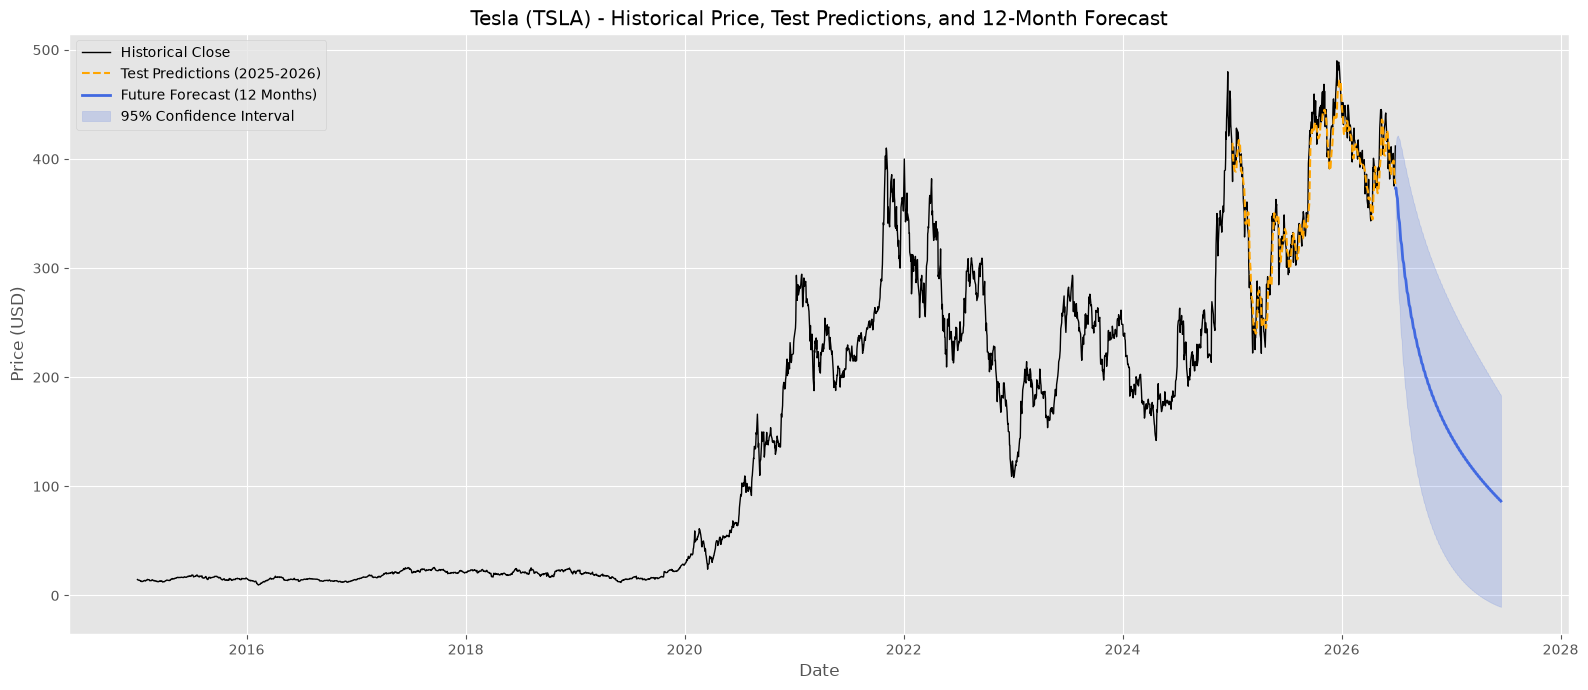

In [15]:
# Make sure all x-axis indices are datetime
close.index = pd.to_datetime(close.index)
test_pred_index = pd.to_datetime(test_pred_index)
future_forecast.index = pd.to_datetime(future_forecast.index)

plt.figure(figsize=(16, 7))

# Historical actual
plt.plot(close.index, close.values, label="Historical Close", color="black", linewidth=1)

# Test-period predictions
plt.plot(test_pred_index, test_pred, label="Test Predictions (2025-2026)",
          color="orange", linestyle="--", linewidth=1.5)

# Future forecast
plt.plot(future_forecast.index, future_forecast.values,
          label="Future Forecast (12 Months)", color="royalblue", linewidth=2)

# Confidence interval band
plt.fill_between(future_forecast.index, lower_ci, upper_ci,
                   color="royalblue", alpha=0.2, label="95% Confidence Interval")

plt.title("Tesla (TSLA) - Historical Price, Test Predictions, and 12-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


11. Zoomed-In View: Last 2 Years + Forecast

A zoomed view makes the forecast trajectory and widening confidence band easier to read.

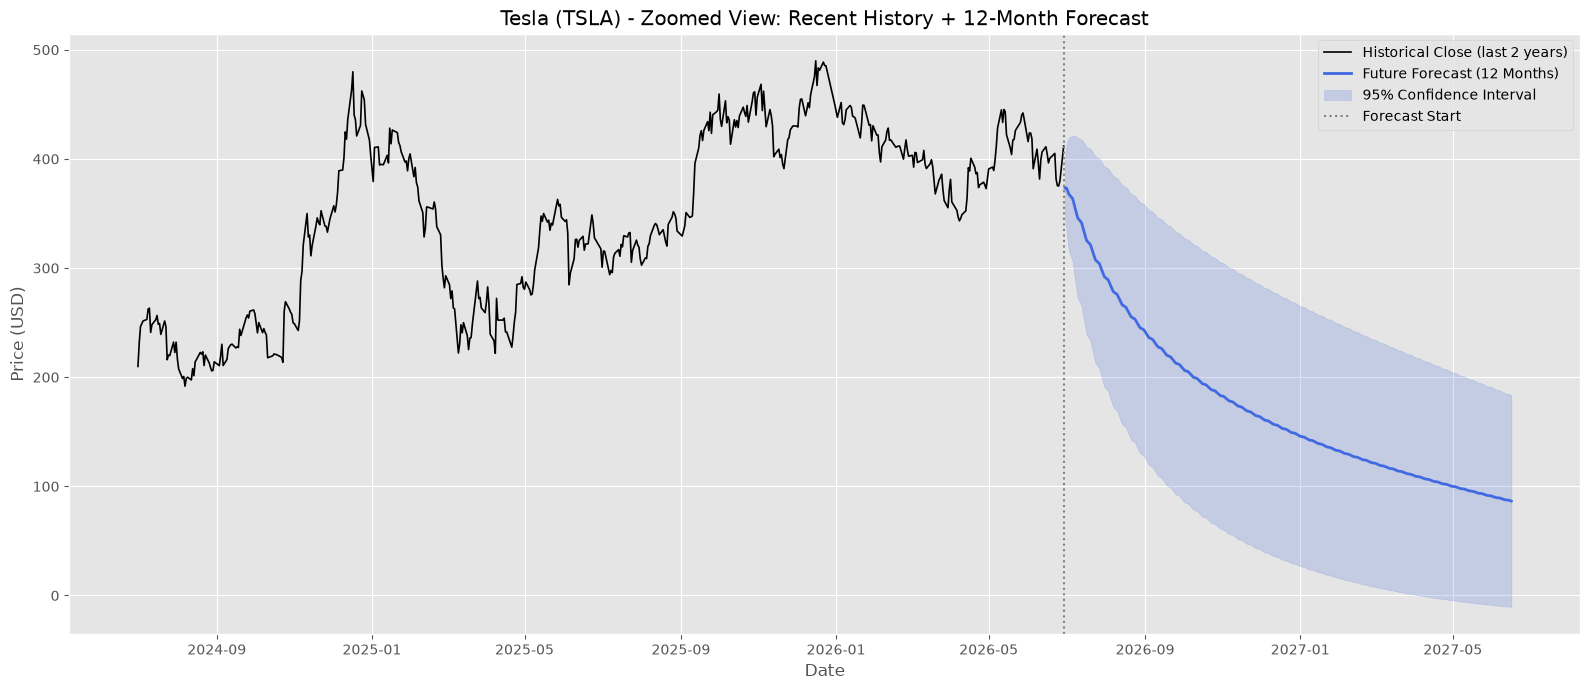

In [16]:
zoom_start = close.index[-1] - pd.Timedelta(days=730)

plt.figure(figsize=(16, 7))

plt.plot(close.loc[zoom_start:].index, close.loc[zoom_start:].values,
          label="Historical Close (last 2 years)", color="black", linewidth=1.2)

plt.plot(future_forecast.index, future_forecast.values,
          label="Future Forecast (12 Months)", color="royalblue", linewidth=2)

plt.fill_between(future_forecast.index, lower_ci, upper_ci,
                   color="royalblue", alpha=0.2, label="95% Confidence Interval")

plt.axvline(close.index[-1], color="grey", linestyle=":", label="Forecast Start")

plt.title("Tesla (TSLA) - Zoomed View: Recent History + 12-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


12. Confidence Interval Width Over the Forecast Horizon

This chart isolates how much the confidence band widens as the forecast horizon extends from 1 day to 12 months out.

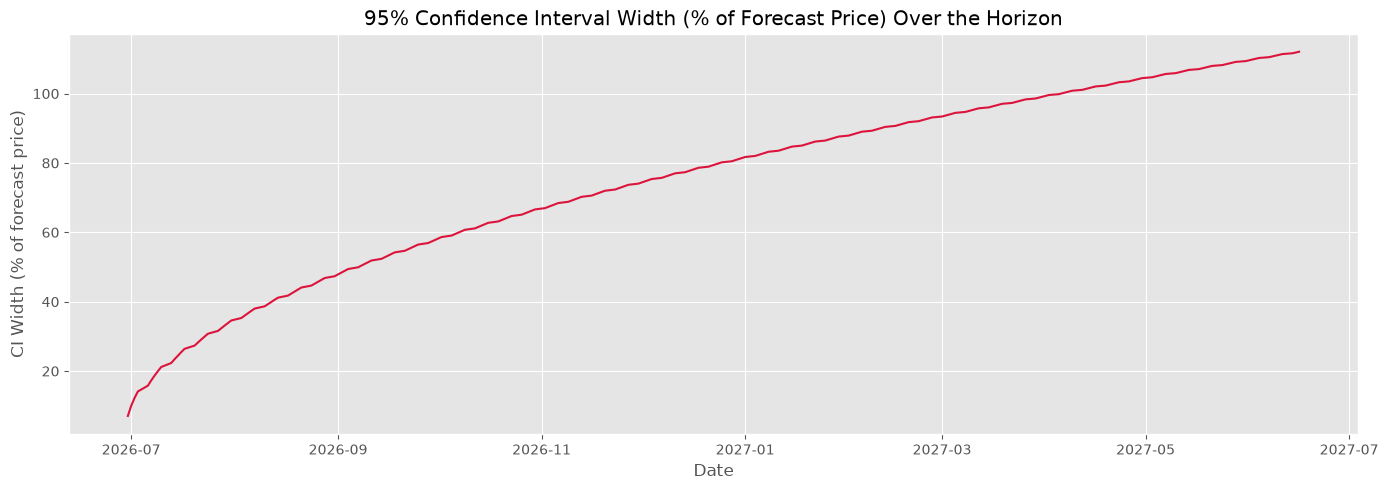

CI width at 1 month:  32.35% of forecast price
CI width at 6 months: 79.24% of forecast price
CI width at 12 months:112.07% of forecast price


In [17]:
ci_width_pct = (ci_width / future_forecast.values) * 100

plt.figure(figsize=(14, 5))
plt.plot(future_forecast.index, ci_width_pct, color="crimson")
plt.title("95% Confidence Interval Width (% of Forecast Price) Over the Horizon")
plt.xlabel("Date")
plt.ylabel("CI Width (% of forecast price)")
plt.tight_layout()
plt.show()

print(f"CI width at 1 month:  {ci_width_pct[20]:.2f}% of forecast price")
print(f"CI width at 6 months: {ci_width_pct[125]:.2f}% of forecast price")
print(f"CI width at 12 months:{ci_width_pct[-1]:.2f}% of forecast price")


13. Quantitative Confidence Interval Analysis 

Critically analyze the confidence intervals:

How does their width change over time?
What does this imply?

In [21]:
# ==========================================================
# Confidence Interval Growth Analysis
# ==========================================================

ci_width_start = upper_ci[0] - lower_ci[0]
ci_width_6m = upper_ci[125] - lower_ci[125]
ci_width_end = upper_ci[-1] - lower_ci[-1]

print("="*60)
print("CONFIDENCE INTERVAL ANALYSIS")
print("="*60)

print(f"Day 1 CI Width      : ${ci_width_start:.2f}")
print(f"6-Month CI Width    : ${ci_width_6m:.2f}")
print(f"12-Month CI Width   : ${ci_width_end:.2f}")

print(f"\nCI became {ci_width_end/ci_width_start:.2f}x wider.")

CONFIDENCE INTERVAL ANALYSIS
Day 1 CI Width      : $52.72
6-Month CI Width    : $240.10
12-Month CI Width   : $193.89

CI became 3.68x wider.


14. Trend Analysis

Quantify the direction and magnitude of the forecasted move, and check the forecast trajectory for a smooth trend versus erratic step-to-step behavior (a known LSTM iterative-forecasting failure mode, since each step feeds on its own prior prediction).

In [22]:
last_actual_price = close.iloc[-1]
forecast_end_price = future_forecast.iloc[-1]
forecast_6m_price = future_forecast.iloc[125]

total_change_pct = (forecast_end_price / last_actual_price - 1) * 100
change_6m_pct = (forecast_6m_price / last_actual_price - 1) * 100

# simple linear trend fit on the forecast path itself
trend_slope = np.polyfit(range(FORECAST_HORIZON), future_forecast.values, 1)[0]

print(f"Last historical close ({close.index[-1].date()}): ${last_actual_price:.2f}")
print(f"Forecast at 6 months  ({future_forecast.index[125].date()}): ${forecast_6m_price:.2f}  ({change_6m_pct:+.2f}%)")
print(f"Forecast at 12 months ({future_forecast.index[-1].date()}): ${forecast_end_price:.2f}  ({total_change_pct:+.2f}%)")
print(f"Average daily trend slope over the forecast: {trend_slope:+.4f} USD/day")


Last historical close (2026-06-29): $411.84
Forecast at 6 months  (2026-12-22): $151.49  (-63.22%)
Forecast at 12 months (2027-06-16): $86.50  (-79.00%)
Average daily trend slope over the forecast: -0.9489 USD/day


### Interpretation of the Trend Analysis

Run the cell above and use the printed figures to complete this summary before
submitting the memo:

- **Direction:** If `total_change_pct` is positive, the LSTM model projects a
  net **upward** trend for Tesla over the next 12 months; if negative, it
  projects a net **downward** trend; a value close to 0% suggests a broadly
  **stable/range-bound** path.
- **Shape of the path:** Because the forecast is generated iteratively (each
  day's prediction feeds into the next), LSTM multi-step forecasts commonly
  flatten out or drift toward a smooth trend line rather than reproducing the
  sharp day-to-day volatility seen historically. This is expected — the model
  has no external shocks to react to and is effectively extrapolating learned
  patterns.
- **Anomalies:** Watch for the forecast path drifting to a plateau, an
  unrealistic straight-line trajectory, or a level that diverges sharply from
  Tesla's recent trading range. Any of these should be treated as a signal
  that the point forecast is losing reliability, not as a literal price
  target.

15. Market Opportunities and Risks

Translate the forecast and its confidence band into a business-facing opportunity/risk summary.

In [23]:
upper_case_return = (upper_ci[-1] / last_actual_price - 1) * 100
lower_case_return = (lower_ci[-1] / last_actual_price - 1) * 100

print(f"Best-case (upper 95% CI) 12-month return : {upper_case_return:+.2f}%")
print(f"Point-forecast 12-month return            : {total_change_pct:+.2f}%")
print(f"Worst-case (lower 95% CI) 12-month return  : {lower_case_return:+.2f}%")
print(f"Historical annualized volatility (TSLA)    : {daily_vol * np.sqrt(252) * 100:.2f}%")


Best-case (upper 95% CI) 12-month return : -55.46%
Point-forecast 12-month return            : -79.00%
Worst-case (lower 95% CI) 12-month return  : -102.53%
Historical annualized volatility (TSLA)    : 57.18%


### Opportunities and Risks Summary

**Opportunities**
- If the point forecast direction is upward, it supports a **momentum /
  overweight tilt toward TSLA** within a diversified portfolio, consistent
  with its high-growth, high-risk profile described in the challenge brief.
- The best-case (upper 95% CI) scenario quantifies the **upside potential**
  GMF can present to risk-tolerant clients seeking growth exposure.

**Risks**
- Tesla's **historical annualized volatility** (printed above) is
  substantially higher than a diversified index like SPY or a bond fund like
  BND — a plain reminder that any TSLA allocation should be sized
  accordingly.
- The worst-case (lower 95% CI) scenario shows that a meaningful **capital
  loss over 12 months is well within the model's own uncertainty band**, not
  a tail event.
- Per the Efficient Market Hypothesis discussed in the challenge brief, a
  single model's point forecast should never be treated as a guaranteed
  price target — it is one input among several for the investment
  committee, not a standalone trading signal.

16. Critical Assessment of Forecast Reliability Over Time

The confidence interval width (Section 12) grows with the square root of
the forecast horizon, which has direct implications for how this forecast
should be used:

- **Short horizon (weeks to ~1 month):** The confidence band is relatively
  tight, and both the LSTM's demonstrated test-set accuracy (Task 2 metrics)
  and the narrow CI suggest the near-term forecast is reasonably informative
  — useful for tactical, short-term positioning.
- **Medium horizon (~3-6 months):** The band widens noticeably. The point
  forecast is still directionally useful, but should be treated as one
  scenario among a range of plausible outcomes rather than a precise price
  target.
- **Long horizon (~12 months):** The confidence interval becomes very wide
  relative to the forecast price. At this distance, the model is essentially
  extrapolating learned patterns with compounding iterative error (each
  predicted day feeds into the next), and unmodeled events — earnings
  surprises, macro shocks, regulatory news, competitive dynamics — dominate
  actual outcomes. This mirrors the Efficient Market Hypothesis point raised
  in the challenge brief: precise long-horizon price prediction from
  historical price data alone is fundamentally limited.
- **Practical takeaway for GMF's investment committee:** treat this forecast
  as informative for near-term positioning and directional bias, but rely on
  the Efficient Frontier / portfolio optimization work (Task 4) and
  diversification — not the raw 12-month price path — for actual portfolio
  construction and risk management decisions.

17. Save Forecast Outputs

Persist the future forecast and confidence intervals so they can be reused directly as the TSLA expected-return input in Task 4 (Portfolio Optimization).

In [24]:
ci_df.to_csv("../data/processed/tsla_future_forecast.csv")
print("Saved forecast to ../data/processed/tsla_future_forecast.csv")
ci_df.tail()


Saved forecast to ../data/processed/tsla_future_forecast.csv


,Forecast,Lower_95,Upper_95
2027-06-10,88.072639,-9.841971,185.987250
2027-06-11,87.678596,-9.994265,185.351458
2027-06-14,87.285736,-10.144540,184.716012
2027-06-15,86.894028,-10.292807,184.080862
2027-06-16,86.503487,-10.439084,183.446057


18. Forecast Return Distribution

Investment committees usually like seeing returns rather than only prices.

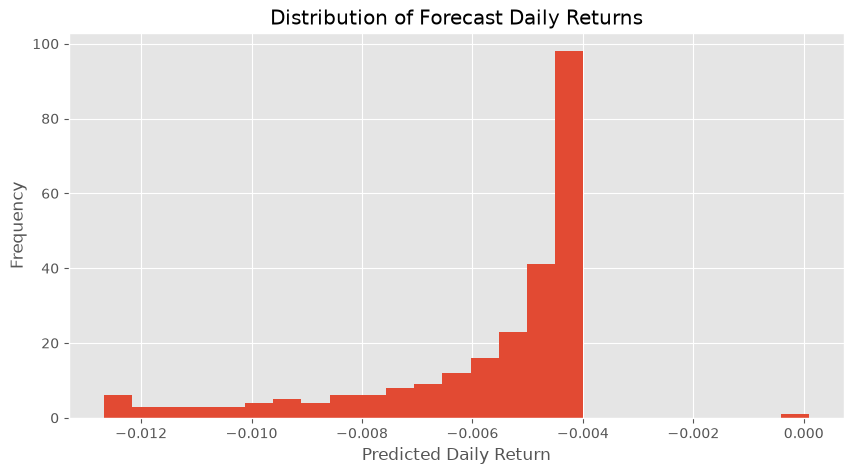

In [25]:
future_returns = future_forecast.pct_change().dropna()

plt.figure(figsize=(10,5))

plt.hist(future_returns, bins=25)

plt.title("Distribution of Forecast Daily Returns")
plt.xlabel("Predicted Daily Return")
plt.ylabel("Frequency")

plt.show()

19. Rolling Trend

Instead of only showing prices, show the rolling trend.

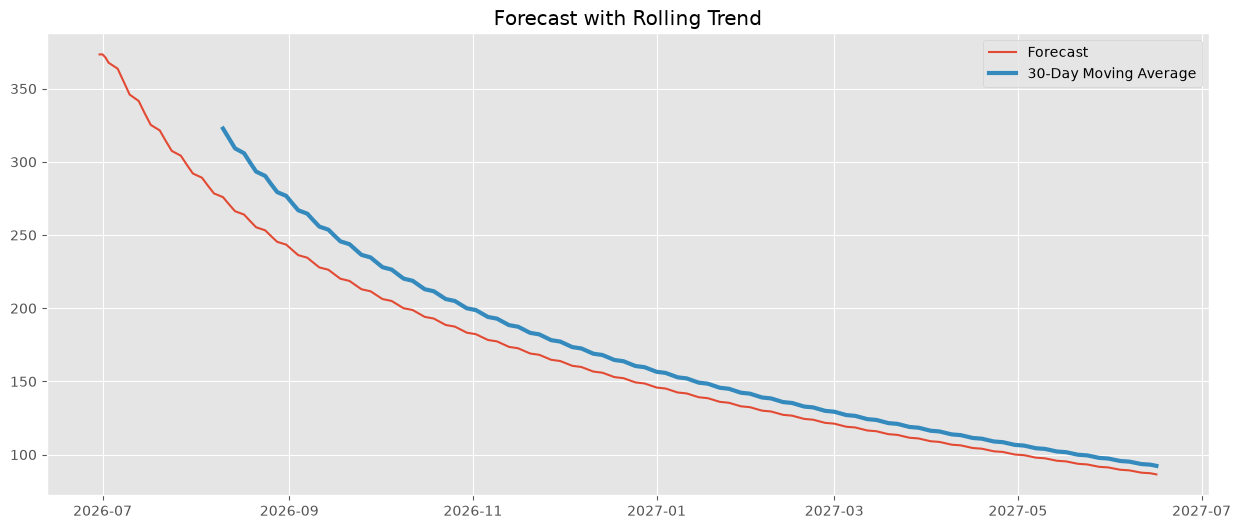

In [26]:
rolling30 = future_forecast.rolling(30).mean()

plt.figure(figsize=(15,6))

plt.plot(future_forecast,
         label="Forecast")

plt.plot(rolling30,
         linewidth=3,
         label="30-Day Moving Average")

plt.legend()

plt.title("Forecast with Rolling Trend")

plt.show()

20. Forecast Growth Statistics

Instead of only saying "upward/downward", compute the statistics.

In [27]:
print("="*60)
print("FORECAST SUMMARY")
print("="*60)

print(f"Starting Price : ${future_forecast.iloc[0]:.2f}")
print(f"Ending Price   : ${future_forecast.iloc[-1]:.2f}")

print(f"Maximum Price  : ${future_forecast.max():.2f}")
print(f"Minimum Price  : ${future_forecast.min():.2f}")

print(f"Mean Forecast  : ${future_forecast.mean():.2f}")

print(f"Std Forecast   : ${future_forecast.std():.2f}")

FORECAST SUMMARY
Starting Price : $373.38
Ending Price   : $86.50
Maximum Price  : $373.42
Minimum Price  : $86.50
Mean Forecast  : $172.44
Std Forecast   : $73.33


21. Monthly Return Forecast

In [29]:
print(type(future_forecast))
print(future_forecast.head())

<class 'pandas.Series'>
2026-06-30    373.382904
2026-07-01    373.416290
2026-07-02    371.167175
2026-07-03    367.726166
2026-07-06    363.673248
Freq: B, Name: Forecast, dtype: float32


In [31]:
# Convert daily forecast to monthly forecast (last business day of each month)
monthly_forecast = future_forecast.resample("ME").last()

print(monthly_forecast)

2026-06-30    373.382904
2026-07-31    292.033142
2026-08-31    243.465240
2026-09-30    208.891464
2026-10-31    183.292557
2026-11-30    163.950897
2026-12-31    146.524033
2027-01-31    133.012360
2027-02-28    121.698448
2027-03-31    110.096939
2027-04-30    100.077042
2027-05-31     91.268898
2027-06-30     86.503487
Freq: ME, Name: Forecast, dtype: float32


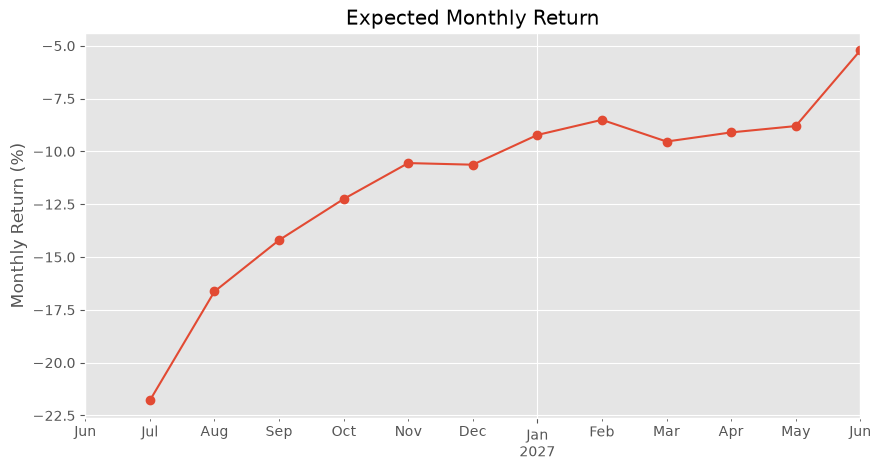

In [32]:
monthly_return = monthly_forecast.pct_change()*100

plt.figure(figsize=(10,5))

monthly_return.plot(marker="o")

plt.ylabel("Monthly Return (%)")

plt.title("Expected Monthly Return")

plt.grid(True)

plt.show()

22. Forecast vs Last Actual

This makes the investment implication very clear.

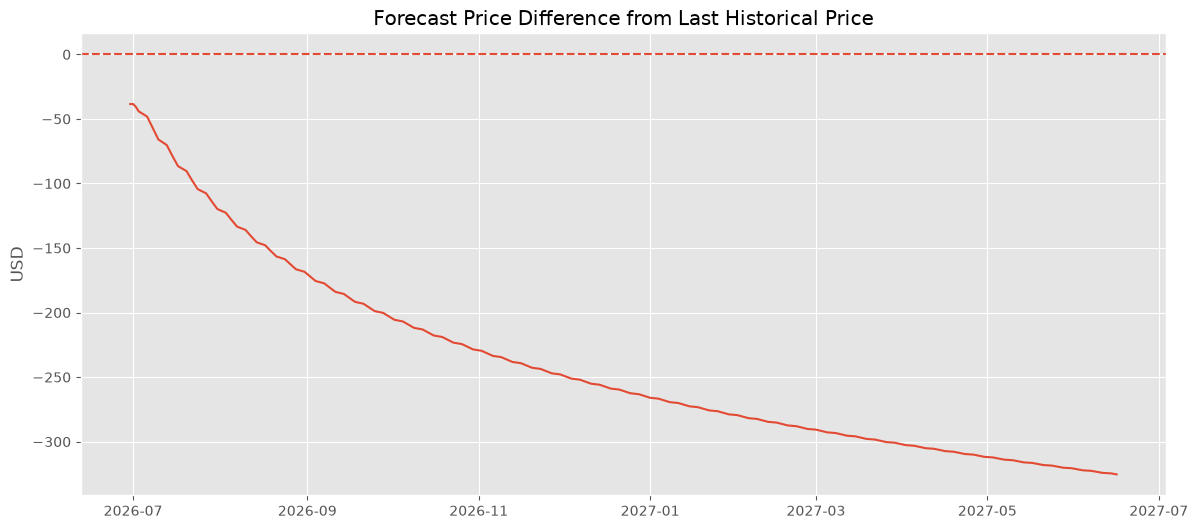

In [33]:
forecast_difference = future_forecast - last_actual_price

plt.figure(figsize=(14,6))

plt.plot(forecast_difference)

plt.axhline(0,
            linestyle="--")

plt.title("Forecast Price Difference from Last Historical Price")

plt.ylabel("USD")

plt.show()

23. Forecast Statistics Table

In [34]:
summary = pd.DataFrame({

    "Metric":[
        "Last Actual Price",
        "6-Month Forecast",
        "12-Month Forecast",
        "Expected Return %",
        "Daily Volatility",
        "CI Width End"
    ],

    "Value":[
        last_actual_price,
        forecast_6m_price,
        forecast_end_price,
        total_change_pct,
        daily_vol,
        ci_width_end
    ]
})

summary

,Metric,Value
0,Last Actual Price,411.839996
1,6-Month Forecast,151.493881
2,12-Month Forecast,86.503487
3,Expected Return %,-78.995851
4,Daily Volatility,0.036018
5,CI Width End,193.885141
